In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import sys
#sys.path.append(r"C:\Users\Michael Ocampo\Documents\P_Files\opensees\final_\functions")
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")

In [3]:
#!sudo apt update
#!sudo apt install libglu1-mesa libglu1-mesa-dev
#!pip install -r requirements.txt

In [4]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import time as tt
import gmsh
import solver_function as SF
import materialParam as param
import RCs_section as RCS
import importlib
importlib.reload(SF)
importlib.reload(param)
importlib.reload(RCS)
from solver_function import *
from materialParam import *
from RCs_section import *

In [5]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (127238260915)>


In [6]:
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 3)

In [7]:
fmass = 1.0 #TON/M^3
fbulk = 1.0 #TON/M^3
smass = 2.0 #TON/M^3
G = 6.0e4
B = 2.4e5
bulk = 2.2e6 
vperm = 5.e-4 / 9.81 / fmass
hperm = 5.e-4 / 9.81 / fmass
accGravity = 9.81 
press = 0.0
loadBias = 0.07
accMul = 2.0
accNam = "whatever.acc"
accDt = 0.0166
period = 1.0
deltaT = 0.01
numSteps = 2400
gamma = 0.6
massDamp = 0.0
stiffDamp = 0.002

In [8]:
medium = param.create_material(ops, param.medium_sand_params, matTag=10, dof=2)
#medium_dense = param.create_material(ops, param.medium_dense_sand_params, matTag=11, dof=2)
#dense = param.create_material(ops, param.dense_sand_params, matTag=12, dof=2)

#ops.nDMaterial("InitialStateAnalysisWrapper", 1, 10, 2)
#ops.nDMaterial("InitialStateAnalysisWrapper", 2, 11, 2)
#ops.nDMaterial("InitialStateAnalysisWrapper", 3, 10, 2)

Will use 10 yield surfaces.


In [9]:
alpha = SF.compute_alpha(h = 1.0, density = 1.9, youngs_modulus = 10.0e3)
print(alpha)

1.8571428571428572e-05


In [10]:
ssp_quadUP_blocks = SF.generate_ssp_quadup_block(
    start_x = 0.0, start_y = 0.0, length = 20.0, height = 10.0, node_offset = 1, elem_offset = 1, 
    material_tag = 10, thickness = 1.0, fluid_bulk = 9.81, #kN/m3
    fluid_mass_density = fmass, horizontal_perm = hperm , vertical_perm = vperm, void = 0.7, alpha = alpha, b1 = 0.0, b2 = -accGravity,
    box_width = 1.0, box_height = 1.0, block_name="block"
)

SSPquadUP element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


In [11]:
fixXY = [1, 1, 0]
fixXonly = [1, 0, 0]
fixYonly = [0, 1, 0]

bottom_a = SF.fix_nodes_by_range(start_id=2, end_id=22, step=1, fixity=fixXY, block_name="fixed_nodes")
left_a = SF.fix_nodes_by_range(start_id=23, end_id=212, step=21, fixity=fixXonly, block_name="fixed_nodes")
right_a = SF.fix_nodes_by_range(start_id=43, end_id=232, step=21, fixity=fixXonly, block_name="fixed_nodes")

In [12]:
dwall_node_coor = [
[13.0 ,  1.0000],
[13.0 ,  2.0000],
[13.0 ,  3.0000],
[13.0 ,  4.0000],
[13.0 ,  5.0000],
[13.0 ,  6.0000],
[13.0 ,  7.0000],
[13.0 ,  8.0000],
[13.0 ,  9.0000],
[13.0 , 10.0000],
]

next_node = SF.get_next_node_id()
Dwall_node = SF.add_nodes_from_coordinates(coord_list = dwall_node_coor, start_id = next_node, block_name = "patch_nodes")
print(Dwall_node)

[233, 234, 235, 236, 237, 238, 239, 240, 241, 242]


In [13]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.2)
print(Iz)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 20e6, 0.2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)
BEAMs = SF.create_disp_beam_column_chain(beam_nodes = Dwall_node, beam_start_id = 8051,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain")

0.0006666666666666669


In [14]:
Dwall_node_eq  = Dwall_node[:5]
print(Dwall_node_eq)
Soil_node_eq = [36 + i * 21 for i in range(5)]
print(Soil_node_eq)
eq_dof = SF.apply_equal_dof_pairs(r_nodes = Dwall_node_eq, c_nodes = Soil_node_eq, dofs=[1, 2,3], block_name="equal_dof_pairs")

[233, 234, 235, 236, 237]
[36, 57, 78, 99, 120]


In [15]:
Dwall_node_zero = Dwall_node[5:10]
print(Dwall_node_zero)
soil_zero = [141 + i * 21 for i in range(5)]
print(soil_zero)    

[238, 239, 240, 241, 242]
[141, 162, 183, 204, 225]


In [16]:
SF.create_zero_length_contact2d_chain(master_node= Dwall_node_zero, slave_node = soil_zero,
                                       Kn = 10, Kt = 1e6, fs = 0.3,
                                       start_id = 90020,
                                       normal = [1, 0],
                                       block_name = "zero_length_contacts")

[90020, 90021, 90022, 90023, 90024]

In [17]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=True, show_nodal_loads = False)

In [18]:
import opstool as opst
OPSVIS = opst.vis.pyvista
ODB = opst.post.CreateODB(
    odb_tag='Contact_beam_test_a',
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [19]:
analysis = opst.anlys.SmartAnalyze(
        analysis = "Transient",
        testType = "NormDispIncr",
        testTol = 1.0e-10,
        testIterTimes = 30,
        testPrintFlag = 0,
        tryAddTestTimes = True,
        normTol = 1000,
        testIterTimesMore = [50],
        tryLooseTestTol = True,
        looseTestTolTo = 1e-3,
        tryAlterAlgoTypes = True,
        algoTypes = [40, 10, 20, 30, 31, 50, 60, 70, 90],# KrylovNewton, ModifiedNewton -initial, NewtonLineSearch, ModifiedNewton
        UserAlgoArgs = None,
        initialStep = None,
        relaxation = 0.5,
        minStep = 1.0e-6,
        debugMode = False,
        printPer = 20,
)

In [20]:
SF.setup_variable_transient_analysis()

In [21]:

print("=== Gravity analysis start ===")

# Enable initial state analysis (soil model reads initial stresses)
#ops.InitialStateAnalysis("on")

# --- Elastic stage ---
#ops.updateMaterialStage("-material", 1, "-stage", 0)
#ops.updateMaterialStage("-material",  2, "-stage", 0)
ops.updateMaterialStage("-material", 3, "-stage", 0)
#ops.setParameter("-val", 0, "-eleRange", 9001, 9022, "friction")
#ops.setParameter("-val", 0, "-eleRange", 9030, 9051, "friction")
#ops.setParameter("-val", 0, "-eleRange", 9070, 9074, "friction")
print("Material set to elastic for gravity loading")

monitor_nodes = list(range(27,41))
# Elastic gravity loading
res = SF.dc_qsa_alt(
    
    monitor_nodes = monitor_nodes,
    dt0 = 10.0,
    disp_tol = 1.0,           # m
    pwp_tol = 0.1,            # kPa
    stg_time = 1*3600,           # s
    monitor_pwp = True,
    dt_min  = 10.0,
    dt_max  = 3600.0,
    growth  = 1.5,
    max_steps  = 5000,
    min_stage_frac_before_pwp  = 0.10,
    verbose  = True,
    analysis = analysis,   # SmartAnalyze
    ODB = ODB,        # optional odb
    p_source = "vel",)              # "vel" or "disp"

print(f"DC-QSA finished in {res.steps} steps, t={res.t_accum:.3f}s")

# Example: manual check of a node
print("Elastic gravity analysis complete")
print("Material set to plastic for gravity loading")

# --- Plastic stage ---
#ops.updateMaterialStage("-material", 1, "-stage", 1)
#ops.updateMaterialStage("-material", 2, "-stage", 1) # 
ops.updateMaterialStage("-material", 3, "-stage", 1)
#ops.setParameter("-val", 1, "-eleRange", 9001, 9022, "friction")
#ops.setParameter("-val", 1, "-eleRange", 9030, 9051, "friction")
#ops.setParameter("-val", 1, "-eleRange", 9070, 9074, "friction")
#ops.InitialStateAnalysis("off")
# Continue with same settings or adjust if needed
# Elastic gravity loading
res = SF.dc_qsa_alt(
    
    monitor_nodes = monitor_nodes,
    dt0 = 10.0,
    disp_tol = 1.0,           # m
    pwp_tol = 0.1,            # kPa
    stg_time = 1*3600,           # s
    monitor_pwp = True,
    dt_min  = 10.0,
    dt_max  = 3600.0,
    growth  = 1.5,
    max_steps  = 5000,
    min_stage_frac_before_pwp  = 0.10,
    verbose  = True,
    analysis = analysis,   # SmartAnalyze
    ODB = ODB,        # optional odb
    p_source = "vel",)              # "vel" or "disp"

print(f"DC-QSA finished in {res.steps} steps, t={res.t_accum:.3f}s")
print("=== Gravity analysis finished ===")


=== Gravity analysis start ===
Material set to elastic for gravity loading

--- DC-QSA Stage Start ---
dt0=10s  disp_tol=1 m  pwp_tol=0.1 kPa  stg_time=3.6e+03 s
min_stage_frac_before_pwp=0.10
step |   t_acc(s) |    dt(s) |  dUmax(m) | dPmax(kPa) | ePmax(kPa) | disp_check | pwp_check | decision

[Initial QS Analysis] Analyzing with dt0=10s...
   1 |     20.000 |       10 | 7.03616e-07 |   0.895093 |    1.74889 | 7.036e-07 < 1.000e+00 | 1.749e+00 >= 1.000e-01 | increase dt
   2 |     35.000 |       15 | 9.30989e-07 |   0.143471 |     1.7451 | 9.310e-07 < 1.000e+00 | 1.745e+00 >= 1.000e-01 | increase dt
   3 |     57.500 |     22.5 | 1.18282e-06 |   0.142806 |    1.60544 | 1.183e-06 < 1.000e+00 | 1.605e+00 >= 1.000e-01 | increase dt


   4 |     91.250 |    33.75 | 1.63892e-06 |   0.320053 |    1.28556 | 1.639e-06 < 1.000e+00 | 1.286e+00 >= 1.000e-01 | increase dt
   5 |    141.875 |    50.62 | 2.04063e-06 |   0.566055 |   0.720684 | 2.041e-06 < 1.000e+00 | 7.207e-01 >= 1.000e-01 | increase dt
   6 |    217.812 |    75.94 | 3.10992e-06 |   0.881444 |    0.18857 | 3.110e-06 < 1.000e+00 | 1.886e-01 >= 1.000e-01 | increase dt
   7 |    331.719 |    113.9 | 3.97402e-06 |    1.20881 |    1.36914 | 3.974e-06 < 1.000e+00 | 1.369e+00 >= 1.000e-01 | increase dt
   8 |    502.578 |    170.9 | 5.67084e-06 |    1.54635 |    2.91549 | 5.671e-06 < 1.000e+00 | 2.915e+00 >= 1.000e-01 | increase dt
   9 |    758.867 |    256.3 | 7.14098e-06 |    1.84653 |    4.76194 | 7.141e-06 < 1.000e+00 | 4.762e+00 >= 1.000e-01 | increase dt
  10 |   1143.301 |    384.4 | 9.48552e-06 |    2.34241 |    6.85314 | 9.486e-06 < 1.000e+00 | 6.853e+00 >= 1.000e-01 | increase dt
  11 |   1719.951 |    576.7 | 1.1536e-05 |    2.83693 |    9.41906 | 1.154e

In [22]:
ops.wipeAnalysis()
ops.setTime(0.0)

In [23]:
elem_to_remove = list(range(187, 194))
for nn in elem_to_remove:
    ops.remove("element", nn)
    
node_to_remove = list(range(219,225))
for nn in node_to_remove:
    ops.remove("node", nn)

SF.setup_variable_transient_analysis()
res = SF.dc_qsa_alt(
    
    monitor_nodes = monitor_nodes,
    dt0 = 0.1,
    disp_tol = 1.0,           # m
    pwp_tol = 0.1,            # kPa
    stg_time = 24*3600,           # s
    monitor_pwp = True,
    dt_min  = 0.1,
    dt_max  = 3600.0,
    growth  = 1.5,
    max_steps  = 5000,
    min_stage_frac_before_pwp  = 0.10,
    verbose  = True,
    analysis = analysis,   # SmartAnalyze
    ODB = ODB,        # optional odb
    p_source = "vel",)              # "vel" or "disp"

print(f"DC-QSA finished in {res.steps} steps, t={res.t_accum:.3f}s")


--- DC-QSA Stage Start ---
dt0=0.1s  disp_tol=1 m  pwp_tol=0.1 kPa  stg_time=8.64e+04 s
min_stage_frac_before_pwp=0.10
step |   t_acc(s) |    dt(s) |  dUmax(m) | dPmax(kPa) | ePmax(kPa) | disp_check | pwp_check | decision

[Initial QS Analysis] Analyzing with dt0=0.1s...
   1 |      0.200 |      0.1 | 1.8047e-05 |  0.0170274 |  0.0286272 | 1.805e-05 < 1.000e+00 | 2.863e-02 < 1.000e-01 | increase dt
   2 |      0.350 |     0.15 | 3.17917e-05 |  0.0172085 |  0.0458356 | 3.179e-05 < 1.000e+00 | 4.584e-02 < 1.000e-01 | increase dt
   3 |      0.575 |    0.225 | 3.77165e-05 |  0.0150876 |  0.0609232 | 3.772e-05 < 1.000e+00 | 6.092e-02 < 1.000e-01 | increase dt
   4 |      0.913 |   0.3375 | 3.97388e-05 | 0.00583914 |  0.0667624 | 3.974e-05 < 1.000e+00 | 6.676e-02 < 1.000e-01 | increase dt
   5 |      1.419 |   0.5063 | 4.01491e-05 | 0.00358839 |  0.0651568 | 4.015e-05 < 1.000e+00 | 6.516e-02 < 1.000e-01 | increase dt
   6 |      2.178 |   0.7594 | 3.99804e-05 |  0.0119893 |  0.0531675 | 3.

In [24]:
elem_to_remove = list(range(167, 174))
for nn in elem_to_remove:
    ops.remove("element", nn)
    
node_to_remove = list(range(198,204))
for nn in node_to_remove:
    ops.remove("node", nn)

SF.setup_variable_transient_analysis()
res = SF.dc_qsa_alt(
    
    monitor_nodes = monitor_nodes,
    dt0 = 0.1,
    disp_tol = 1.0,           # m
    pwp_tol = 0.1,            # kPa
    stg_time = 24*3600,           # s
    monitor_pwp = True,
    dt_min  = 0.1,
    dt_max  = 3600.0,
    growth  = 1.5,
    max_steps  = 5000,
    min_stage_frac_before_pwp  = 0.10,
    verbose  = True,
    analysis = analysis,   # SmartAnalyze
    ODB = ODB,        # optional odb
    p_source = "vel",)              # "vel" or "disp"

print(f"DC-QSA finished in {res.steps} steps, t={res.t_accum:.3f}s")


--- DC-QSA Stage Start ---
dt0=0.1s  disp_tol=1 m  pwp_tol=0.1 kPa  stg_time=8.64e+04 s
min_stage_frac_before_pwp=0.10
step |   t_acc(s) |    dt(s) |  dUmax(m) | dPmax(kPa) | ePmax(kPa) | disp_check | pwp_check | decision

[Initial QS Analysis] Analyzing with dt0=0.1s...
   1 |      0.200 |      0.1 | 1.0782e-05 |  0.0360257 |  0.0547736 | 1.078e-05 < 1.000e+00 | 5.477e-02 < 1.000e-01 | increase dt
   2 |      0.350 |     0.15 | 3.71898e-05 |  0.0367203 |  0.0906413 | 3.719e-05 < 1.000e+00 | 9.064e-02 < 1.000e-01 | increase dt
   3 |      0.575 |    0.225 | 5.33081e-05 |   0.032942 |   0.123583 | 5.331e-05 < 1.000e+00 | 1.236e-01 >= 1.000e-01 | increase dt
   4 |      0.913 |   0.3375 | 6.19554e-05 |  0.0219269 |   0.144621 | 6.196e-05 < 1.000e+00 | 1.446e-01 >= 1.000e-01 | increase dt
   5 |      1.419 |   0.5063 | 6.65565e-05 |  0.0071223 |    0.15161 | 6.656e-05 < 1.000e+00 | 1.516e-01 >= 1.000e-01 | increase dt
   6 |      2.178 |   0.7594 | 6.90499e-05 | 0.00393758 |   0.151172 |

In [25]:
elem_to_remove = list(range(147, 154))
for nn in elem_to_remove:
    ops.remove("element", nn)
    
node_to_remove = list(range(177,183))
for nn in node_to_remove:
    ops.remove("node", nn)

SF.setup_variable_transient_analysis()
res = SF.dc_qsa_alt(
    
    monitor_nodes = monitor_nodes,
    dt0 = 0.1,
    disp_tol = 1.0,           # m
    pwp_tol = 0.1,            # kPa
    stg_time = 24*3600,           # s
    monitor_pwp = True,
    dt_min  = 0.1,
    dt_max  = 3600.0,
    growth  = 1.5,
    max_steps  = 5000,
    min_stage_frac_before_pwp  = 0.10,
    verbose  = True,
    analysis = analysis,   # SmartAnalyze
    ODB = ODB,        # optional odb
    p_source = "vel",)              # "vel" or "disp"

print(f"DC-QSA finished in {res.steps} steps, t={res.t_accum:.3f}s")


--- DC-QSA Stage Start ---
dt0=0.1s  disp_tol=1 m  pwp_tol=0.1 kPa  stg_time=8.64e+04 s
min_stage_frac_before_pwp=0.10
step |   t_acc(s) |    dt(s) |  dUmax(m) | dPmax(kPa) | ePmax(kPa) | disp_check | pwp_check | decision

[Initial QS Analysis] Analyzing with dt0=0.1s...
   1 |      0.200 |      0.1 | 3.74362e-05 |  0.0692748 |   0.105442 | 3.744e-05 < 1.000e+00 | 1.054e-01 >= 1.000e-01 | increase dt
   2 |      0.350 |     0.15 | 1.22563e-05 |  0.0709065 |   0.175824 | 1.226e-05 < 1.000e+00 | 1.758e-01 >= 1.000e-01 | increase dt
   3 |      0.575 |    0.225 | 1.81053e-05 |  0.0651648 |   0.240973 | 1.811e-05 < 1.000e+00 | 2.410e-01 >= 1.000e-01 | increase dt
   4 |      0.913 |   0.3375 | 2.59852e-05 |  0.0428205 |   0.283025 | 2.599e-05 < 1.000e+00 | 2.830e-01 >= 1.000e-01 | increase dt
   5 |      1.419 |   0.5063 | 3.13409e-05 |  0.0182941 |   0.301319 | 3.134e-05 < 1.000e+00 | 3.013e-01 >= 1.000e-01 | increase dt
   6 |      2.178 |   0.7594 | 3.68562e-05 | 0.00655687 |   0.30188

In [26]:
elem_to_remove = list(range(127, 134))
for nn in elem_to_remove:
    ops.remove("element", nn)
    
node_to_remove = list(range(156,162))
for nn in node_to_remove:
    ops.remove("node", nn)

SF.setup_variable_transient_analysis()
res = SF.dc_qsa_alt(
    
    monitor_nodes = monitor_nodes,
    dt0 = 0.1,
    disp_tol = 1.0,           # m
    pwp_tol = 0.1,            # kPa
    stg_time = 24*3600,           # s
    monitor_pwp = True,
    dt_min  = 0.1,
    dt_max  = 3600.0,
    growth  = 1.5,
    max_steps  = 5000,
    min_stage_frac_before_pwp  = 0.10,
    verbose  = True,
    analysis = analysis,   # SmartAnalyze
    ODB = ODB,        # optional odb
    p_source = "vel",)              # "vel" or "disp"

print(f"DC-QSA finished in {res.steps} steps, t={res.t_accum:.3f}s")


--- DC-QSA Stage Start ---
dt0=0.1s  disp_tol=1 m  pwp_tol=0.1 kPa  stg_time=8.64e+04 s
min_stage_frac_before_pwp=0.10
step |   t_acc(s) |    dt(s) |  dUmax(m) | dPmax(kPa) | ePmax(kPa) | disp_check | pwp_check | decision

[Initial QS Analysis] Analyzing with dt0=0.1s...
   1 |      0.200 |      0.1 | 5.44146e-05 |  0.0921635 |   0.146152 | 5.441e-05 < 1.000e+00 | 1.462e-01 >= 1.000e-01 | increase dt
   2 |      0.350 |     0.15 | 5.00779e-05 |  0.0956524 |   0.241804 | 5.008e-05 < 1.000e+00 | 2.418e-01 >= 1.000e-01 | increase dt
   3 |      0.575 |    0.225 | 4.24604e-05 |  0.0881317 |   0.329478 | 4.246e-05 < 1.000e+00 | 3.295e-01 >= 1.000e-01 | increase dt
   4 |      0.913 |   0.3375 | 3.54556e-05 |  0.0584934 |   0.387972 | 3.546e-05 < 1.000e+00 | 3.880e-01 >= 1.000e-01 | increase dt
   5 |      1.419 |   0.5063 | 3.00404e-05 |  0.0268965 |   0.414868 | 3.004e-05 < 1.000e+00 | 4.149e-01 >= 1.000e-01 | increase dt
   6 |      2.178 |   0.7594 | 2.6145e-05 | 0.00725258 |   0.417327

In [27]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=True, show_nodal_loads = False)

In [28]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = Contact_beam_test_a saved in 
.opstool.output/RespStepData-Contact_beam_test_a.nc!

In [29]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

In [30]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Contact_beam_test_a.nc ...

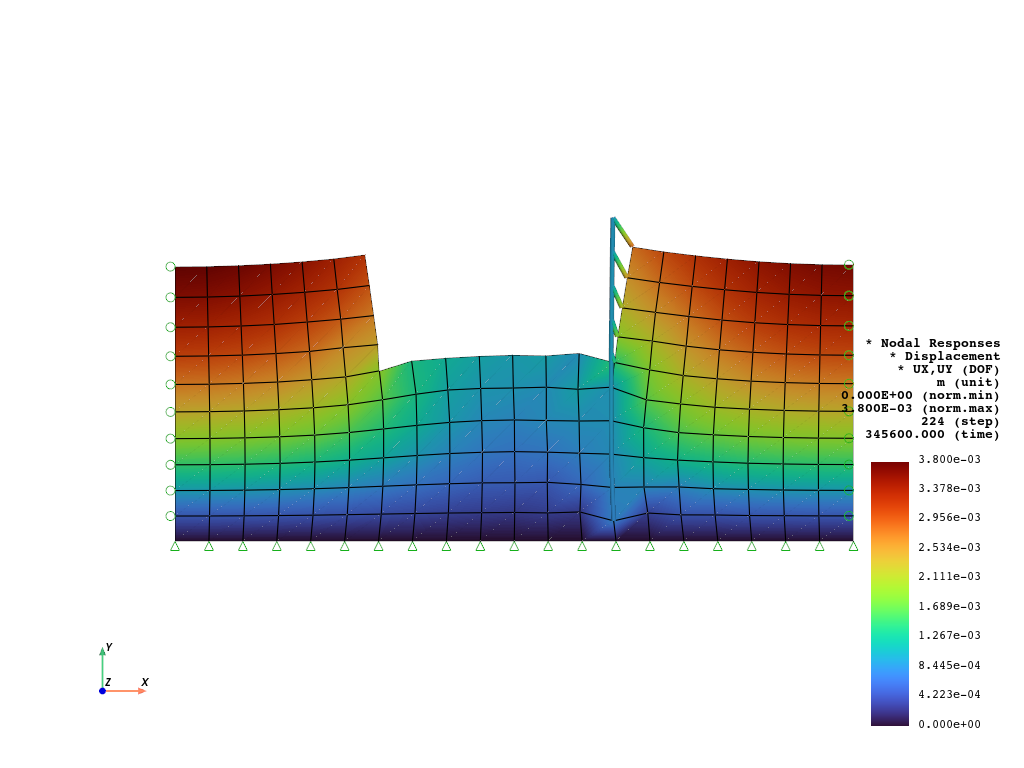

In [36]:
opsvis.plot_nodal_responses(
    odb_tag="Contact_beam_test_a",
    slides=True,
    defo_scale=500.0,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

In [32]:
for nd in [217, 225]:
    ux = ops.nodeDisp(nd, 1)
    uy = ops.nodeDisp(nd, 2)
    try:
        p = ops.nodeVel(nd, 3)
    except Exception:
        p = 0.0
    print(f"Node {nd}: ux={ux:.6e}, uy={uy:.6e}, p={p:.6e}")

Node 217: ux=-6.423165e-04, uy=-3.328210e-03, p=-6.781776e+01
Node 225: ux=9.644923e-04, uy=-2.621519e-03, p=-6.554285e+01


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Contact_beam_test_a.nc ...

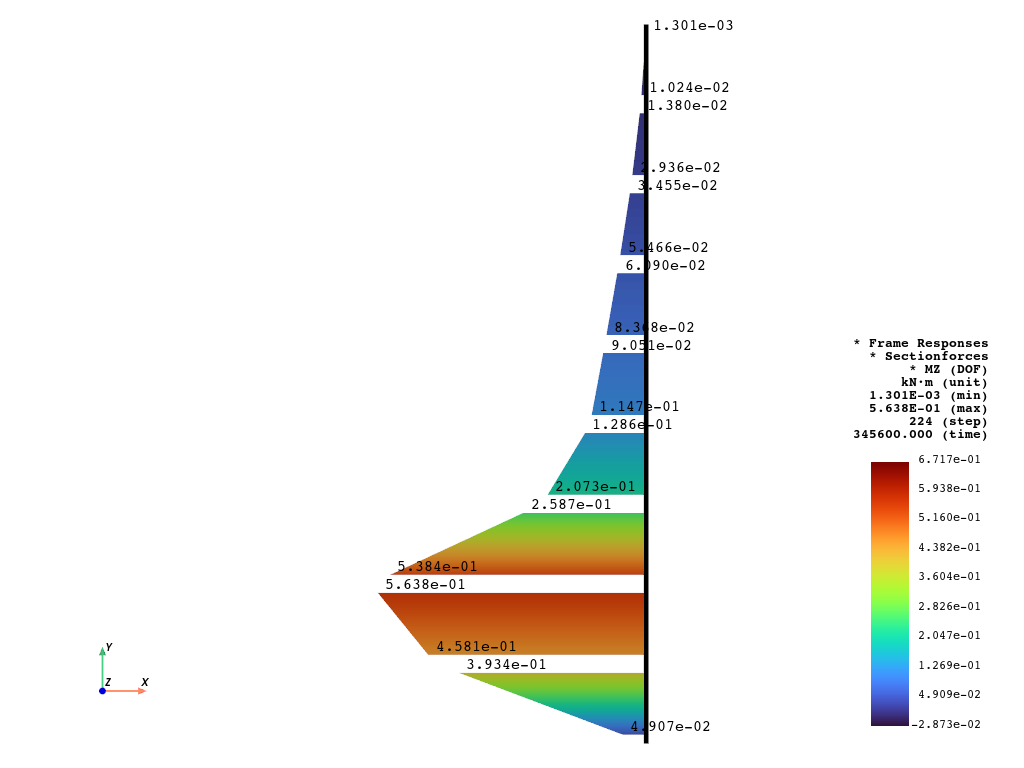

In [33]:
plotter = opsvis.plot_frame_responses(
    odb_tag="Contact_beam_test_a",
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="juoyterlab")

In [34]:
opsvis.plot_frame_responses_animation(
    odb_tag="Contact_beam_test_a",
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values=False,
    framerate=2,
    scale=3,
    style="surface",
    opacity=1.0,
    show_model=True,  # plot all model
    show_bc=False,
    savefig="FrameForcesMZ.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Contact_beam_test_a.nc ...

Animation has been saved as FrameForcesMZ.gif!


In [35]:
opsvis.plot_nodal_responses_animation(
    odb_tag="Contact_beam_test_a",
    framerate=2,
    defo_scale=3.0,
    savefig="NodalRespAnimation.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Contact_beam_test_a.nc ...

Animation has been saved to NodalRespAnimation.gif!
